<a href="https://colab.research.google.com/github/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/blob/main/Notebooks/neural_network_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NEURAL NETWORK FROM SCRATCH**

**IMPORT LIBRARIES**

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


**DEFINE CLASS**

In [45]:
class NeuralNetwork():
  """Representation of a neural network"""

  def __init__(self, learning_rate:float, input_size:int, layers:list, epochs:int , paradigm:str):

    """Initialize the neural network"""

    self.learning_rate = learning_rate
    self.layers = layers
    self.epochs = epochs
    self.input_size=input_size
    self.paradigm=paradigm
    self.count_layers =len(layers)
    self.cost_history=[]
    self.accuracy_history=[]
    self.initialize_weights()
    self.initialize_biases()

  @classmethod
  def empty_neural_network(cls):

    """return a empty  NeuralNetwork object"""

    neural_network=cls.__new__(cls)
    return neural_network

  def initialize_weights(self):

    """Initialize the weights of the neural network with random numbers between 1 and 0 using the kaiming standard deviation"""

    self.weights = []
    for current_layer in range(self.count_layers):
      layer_size = self.layers[current_layer]
      if current_layer == 0:
        shape=(layer_size, self.input_size)
      else:
        layer_before = current_layer-1
        layer_before_size = self.layers[layer_before]
        shape=(layer_size ,layer_before_size)
      standard_deviation = np.sqrt(2/shape[1])
      self.weights.append(np.random.normal(0, standard_deviation,size=shape))

  def initialize_biases(self):

    """Initialize the biases of the neural network with random numbers between 1 and 0"""

    self.biases=[]
    for current_layer in range(self.count_layers):
      layer_size = self.layers[current_layer]
      shape=(layer_size,1)
      self.biases.append(np.zeros(shape))

  def get_relu_activation(self,z:int):

    """Get the relu activation of the net input of a neural network"""
    return np.where(z > 0, z, 0)


  def get_softmax_activation(self,z:int):

    """Get the softmax activation of last layer of the neural network"""

    return np.exp(z)/  np.sum(np.exp(z))

  def get_layer_activations(self,sample_features:np.ndarray):

    """Get the activation of the neurons of the neural network"""

    current_activations = sample_features
    layer_activations = []
    for current_layer in range(self.count_layers):
      net_input = (self.weights[current_layer] @ current_activations)+self.biases[current_layer]
      if(current_layer==self.count_layers-1 and self.paradigm=="classification"):
        net_input_normalized = net_input-np.max(net_input)
        current_activations = self.get_softmax_activation(net_input_normalized)
      else :current_activations= self.get_relu_activation(net_input)
      layer_activations.append(current_activations)
    return layer_activations

  def backpropagation(self,layer_activations:np.ndarray, sample:np.ndarray,label:np.ndarray):

    """Calculate the gradient of the weights and biases"""

    weights_gradients=[]
    biases_gradients=[]
    last_layer=self.count_layers-1
    first_layer=0
    for current_layer in range(last_layer,-1,-1):
      layer_activation= layer_activations[current_layer]
      if(current_layer == last_layer and self.paradigm=="classification"):
        layer_errors=layer_activation - label
      activation_derivative =  np.where(layer_activation > 0, 1, 0)
      if( current_layer == last_layer and self.paradigm=="regression"):
        layer_errors=2*(layer_activation - label)*activation_derivative
      if(current_layer!=last_layer):
        cost_derivative = np.transpose(self.weights[current_layer+1]) @ layer_errors
        layer_errors=cost_derivative * activation_derivative
      if(current_layer==first_layer): input_layer= np.transpose(sample)
      else:input_layer= np.transpose(layer_activations[current_layer-1])
      weights_derivative = layer_errors @ input_layer
      biases_derivative=layer_errors
      weights_gradients.insert(0,weights_derivative)
      biases_gradients.insert(0,biases_derivative)

    return weights_gradients, biases_gradients


  def optimization(self,weights_gradients:np.ndarray,biases_gradients:np.ndarray):

    "update the weights and the biases of the neural network to minimize the cost using gradient descent"

    for current_layer in range(self.count_layers):
      self.weights[current_layer] += -1*self.learning_rate*weights_gradients[current_layer]
      self.biases[current_layer] += -1*self.learning_rate*biases_gradients[current_layer]

  def fit(self, samples:np.ndarray,labels:np.ndarray):

    """Train neural network and stores cost history and accuracy history"""

    count_samples = samples.shape[0]
    with tqdm(total=self.epochs) as pbar:
      for i in range (self.epochs):
        accuracy= 0
        cost = 0
        indices=np.random.permutation(count_samples)
        for j in indices:
          sample = samples[j][:,None]
          label= labels[j]
          layer_activations=self.get_layer_activations(sample)
          weights_gradients, biases_gradients= self.backpropagation(layer_activations,sample,label[:,None])
          self.optimization(weights_gradients,biases_gradients)
        for j in range (count_samples):
          sample = samples[j][:,None]
          label= labels[j]
          layer_activations=self.get_layer_activations(sample)
          prediction=layer_activations[-1]
          if(self.paradigm=="classification"):
            cost+=-np.log(prediction[label==1])[0][0]
            is_prediction_correct=(label[np.argmax(prediction)]==1)
            if(is_prediction_correct): accuracy+=1
          elif(self.paradigm=="regression"):
            cost+=sum((label[:,None] - prediction)**2)[0]
        cost/=count_samples
        self.cost_history.append(cost)
        if(self.paradigm=="classification"):
          accuracy/=count_samples
          self.accuracy_history.append(accuracy)
        pbar.update(1)


  def plot_cost_history(self):

    """plot the value of the cost function for each epoch on the training process"""

    ax[0].plt.plot(range(1,len(self.cost_history)+1),self.cost_history)
    plt.xlabel("epoch")
    plt.ylabel("cost")
    plt.title("history of cost function")

  def plot_accuracy_history(self):

    """plot the value of the  average accuracy for each epoch on the training process"""

    if(self.paradigm=="regression"): return
    plt.plot(range(1,len(self.accuracy_history)+1),self.accuracy_history)
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("history of accuracy")



  def predict(self,sample:np.ndarray):

    """Returns the activation of the last layout for a sample"""

    return self.get_layer_activations(sample)[-1]

  def save(self, path:str):

    """save the attributes of the neural network on the given path"""

    np.savez(
        path,
        weights=np.array(self.weights, dtype=object),
        biases=np.array(self.biases, dtype=object),
        cost_history=self.cost_history,
        layers=self.layers,
        input_size=self.input_size,
        count_layers=self.count_layers,
        learning_rate=self.learning_rate,
        epochs=self.epochs,
        paradigm=self.paradigm
    )

  def load(self, path:str):

    """load the attributes to the neural network from the given path"""

    data = np.load(path, allow_pickle=True)
    self.weights = list(data["weights"])
    self.biases = list(data["biases"])
    self.cost_history= list(data["cost_history"])
    self.count_layers=data["count_layers"]
    self.input_size=data["input_size"]
    self.layers=list(data["layers"])
    self.learning_rate=data["learning_rate"]
    self.epochs=data["epochs"]
    self.paradigm=data["paradigm"]






**GRAPH  OF COST VS NEURON'S PROBABILITY OF CHOOSE THE CORRECT CLASS**

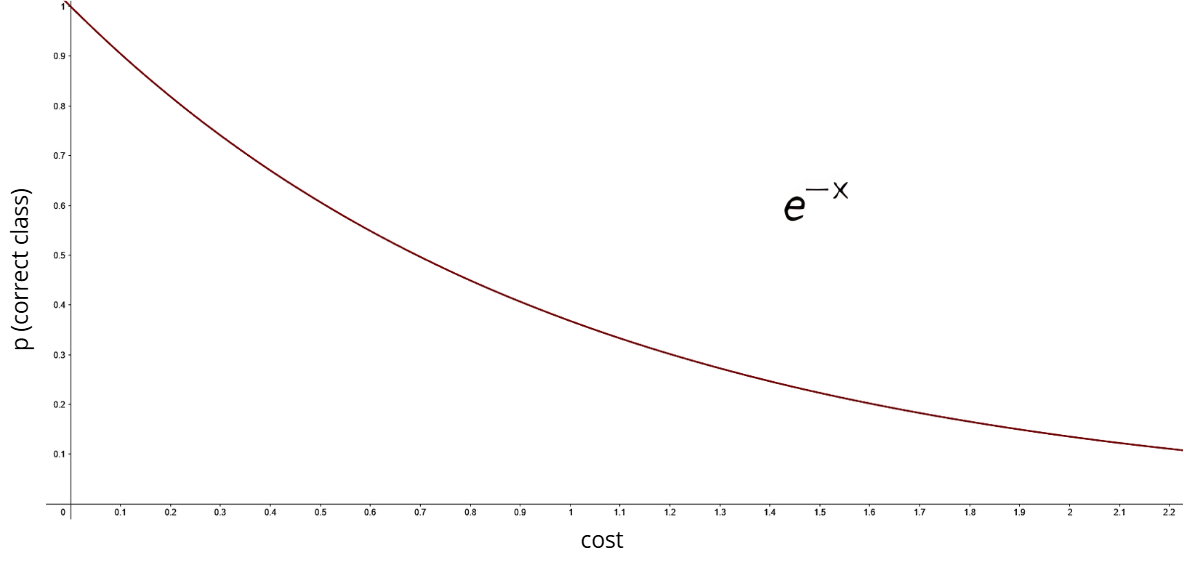

# **TEST NEURAL NETWORK**

**UNIT TESTS**

In [ ]:
#Test weights' initialization

model= NeuralNetwork(0.1,2,[110,3],5,"regression")
model.initialize_weights()
print(model.weights)

[array([[-1.06998244, -1.23906174],
       [-2.24639655,  1.08421311],
       [ 1.17650598,  0.3690412 ],
       [-0.02685027, -1.63394616],
       [-0.80930344, -0.54899997],
       [-0.90349484,  0.63218058],
       [ 0.15899213,  1.55135004],
       [-1.73673559,  1.2623999 ],
       [-2.04143564,  1.19868656],
       [-0.54504291, -0.56332295],
       [-0.01794329, -1.8494191 ],
       [-1.88208435, -1.35774707],
       [ 1.34751331,  0.16489217],
       [ 0.04051022,  0.45500254],
       [ 1.53896843, -0.99420774],
       [-0.14863067, -0.0901035 ],
       [-1.30214153, -0.964202  ],
       [-1.97928878,  1.6489529 ],
       [ 1.28294298, -2.15219722],
       [ 0.5838733 , -0.28537838],
       [ 1.24289234, -0.20306025],
       [-0.93284703,  0.11455432],
       [-0.36019233, -0.15138107],
       [ 0.69526372, -1.90850519],
       [-0.2712547 , -1.61353395],
       [-0.77028144, -0.01630694],
       [ 0.73160193,  0.33359858],
       [ 0.17299248,  0.86275575],
       [ 0.34660127

In [ ]:
#Test biases' initialization

model= NeuralNetwork(0.1,1,[2,2,1,2,1,1],5,"classification")
model.initialize_biases()
print(model.biases)

[array([[0.],
       [0.]]), array([[0.],
       [0.]]), array([[0.]]), array([[0.],
       [0.]]), array([[0.]]), array([[0.]])]


In [25]:
#Test neuron' activations

model= NeuralNetwork(0.1,110,[110,2],5,"classification")
model.initialize_weights()
model.initialize_biases()
arr = np.zeros(110, dtype=int)
arr[10] = 1
arr[50] = 1
sample=np.array(arr)[:,None]
print(model.get_layer_activations(sample)[-1])

[[0.45487889]
 [0.54512111]]


In [27]:
#Test neuron saving and loading

path = "/content/drive/MyDrive/my_neural_network"
model= NeuralNetwork(0.1,110,[3,1],1,"regression")
model.save(path)
print("Initial neural network")
print(model.weights)
print(model.biases)
print(model.learning_rate)

model2=NeuralNetwork.empty_neural_network()
model2.load(path+".npz")
print(" ")
print("neural network saved")
print(model2.weights)
print(model2.biases)
print(model2.learning_rate)

Initial neural network
[array([[-0.19785698, -0.02549325,  0.04101737,  0.02256501, -0.02373651,
        -0.04109911,  0.30918928,  0.10015005, -0.0333832 ,  0.10365901,
         0.04358442,  0.23040832,  0.15290182, -0.28978982,  0.05892139,
        -0.01240934, -0.02376442,  0.13758617,  0.15077017,  0.17238546,
        -0.01660147,  0.1971687 ,  0.06635501,  0.21001899, -0.08916405,
        -0.13668796, -0.1466801 , -0.12243895,  0.03584055,  0.042735  ,
         0.0261769 , -0.05416816,  0.05554968,  0.1155803 , -0.03133624,
         0.01926691, -0.20115841,  0.08099914,  0.06018022,  0.02860114,
         0.06153118, -0.10391627, -0.10140438, -0.09933883,  0.04609663,
         0.08818471, -0.14484774, -0.0166431 ,  0.01750183, -0.08636808,
        -0.054052  , -0.11172593, -0.03207928,  0.20739295,  0.06463044,
        -0.02776128,  0.12736962, -0.01844827, -0.20725476, -0.08648627,
         0.16431423, -0.08415425,  0.1233694 , -0.0444868 , -0.22546446,
        -0.29804183, -0.168

# **EXPERIMENTS WITH NEURAL NETWORK**

**ID OF TEAMS**

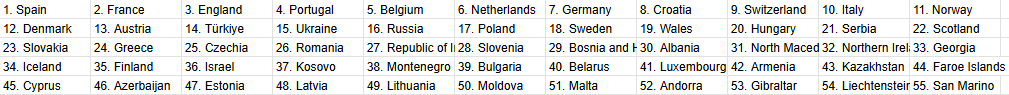

**CHARGE SOCCER CLASSIFICATION DATASET**

In [28]:
!wget https://raw.githubusercontent.com/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/main/Sources/historical_european_soccer_matches.csv
df=pd.read_csv('historical_european_soccer_matches.csv')

--2026-08-27 14:57:06--  https://raw.githubusercontent.com/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/main/Sources/historical_european_soccer_matches.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3047567 (2.9M) [text/plain]
Saving to: ‘historical_european_soccer_matches.csv’

historical_european 100%[===================>]   2.91M  --.-KB/s    in 0.04s   

2026-08-27 14:57:06 (72.1 MB/s) - ‘historical_european_soccer_matches.csv’ saved [3047567/3047567]



**TRAIN CLASSIFICATION NEURAL NETWORK**


100%|██████████| 500/500 [41:37<00:00,  5.00s/it]


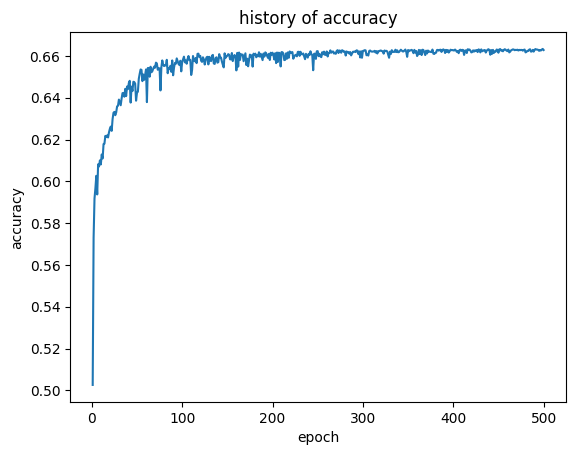

In [48]:
samples= df.iloc[:,:-5].values
labels= df.iloc[:,-3:].values
columns_count=samples.shape[1]
model= NeuralNetwork(0.001,columns_count,[110,110,110,3],500,"classification")
model.fit(samples,labels)
model.plot_accuracy_history()
path = "/content/drive/MyDrive/classification_soccer_predictor.npz"
#model.save(path)


**GET PREDICTIONS OF THE NEURAL NETWORK**

In [49]:
def arg_max_prediction(predictions):
  if(np.max(predictions)==predictions[0][0]):
    print("The home team wins")
  elif(np.max(predictions)==predictions[1][0]):
    print("The away team wins")
  elif(np.max(predictions)==predictions[2][0]):
    print("The teams draw")

while True:
  id_home_team=int(input("type a home team by its id : ")) - 1
  id_away_team=int(input("type a away team by its id : ")) + 54
  sample=np.zeros(110)
  sample[id_home_team]=1
  sample[id_away_team]=1
  sample=sample[:,None]
  arg_max_prediction(model.predict(sample))

type a home team by its id : 1
type a away team by its id : 55
The home team wins
type a home team by its id : 1
type a away team by its id : 34
The home team wins


KeyboardInterrupt: Interrupted by user

**TRAIN REGRESSION NEURAL NETWORK**

100%|██████████| 500/500 [37:18<00:00,  4.48s/it]


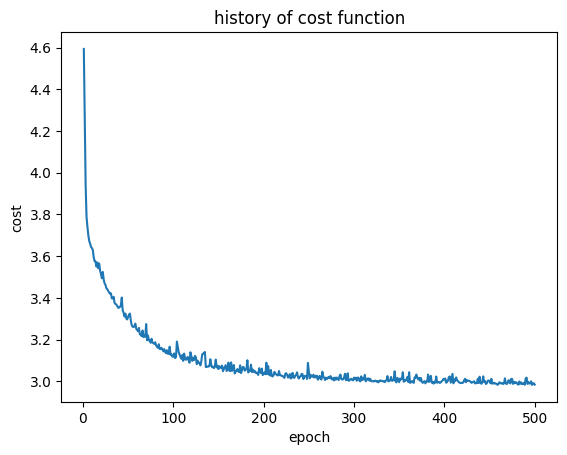

In [33]:
samples= df.iloc[:,:-5].values
labels= df.iloc[:,-5:-3].values
columns_count=samples.shape[1]
model= NeuralNetwork(0.0001,columns_count,[110,110,110,2],500,"regression")
model.fit(samples,labels)
model.plot_cost_history()
path = "/content/drive/MyDrive/regression_soccer_predictor.npz"
model.save(path)

**GET PREDICTIONS OF THE NEURAL NETWORK**

In [ ]:
while True:
  id_home_team=int(input("type a home team by its id : ")) - 1
  id_away_team=int(input("type a away team by its id : ")) + 54
  sample=np.zeros(110)
  sample[id_home_team]=1
  sample[id_away_team]=1
  sample=sample[:,None]
  results=model.predict(sample)
  home_team_score=round(results[0][0])
  away_team_score=round(results[1][0])
  print("The home team score is : ",home_team_score)
  print("The away team score is : ",away_team_score)

type a home team by its id : 1
type a away team by its id : 55
The home team score is :  7
The away team score is :  0
type a home team by its id : 1
type a away team by its id : 53
The home team score is :  6
The away team score is :  0
type a home team by its id : 1
type a away team by its id : 54
The home team score is :  5
The away team score is :  0
type a home team by its id : 1
type a away team by its id : 10
The home team score is :  1
The away team score is :  1
type a home team by its id : 1
type a away team by its id : 11
The home team score is :  2
The away team score is :  0
type a home team by its id : 3
type a away team by its id : 4
The home team score is :  1
The away team score is :  1
type a home team by its id : 3
type a away team by its id : 4
The home team score is :  1
The away team score is :  1
type a home team by its id : 3
type a away team by its id : 14
The home team score is :  3
The away team score is :  0
type a home team by its id : 14
type a away team b